# Draw Azimut and Elevation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


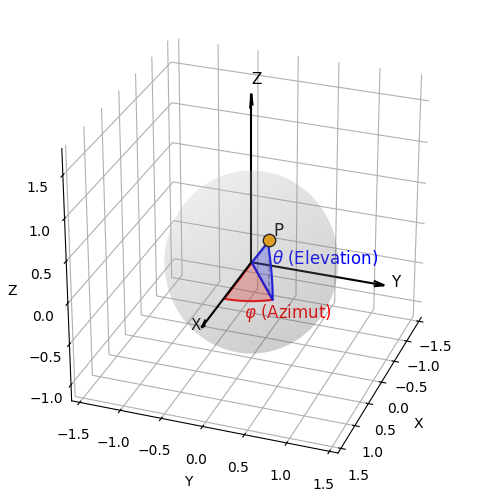

In [2]:
def plot_unit_sphere():
    u = np.linspace(0, 2 * np.pi, 160)
    v = np.linspace(0, np.pi, 160)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))
    return x, y, z

def coordinate_axes(ax):
    # Coordinate axes as arrows
    ax.quiver(0, 0, 0, 1.6, 0,   0, color='k', arrow_length_ratio=0.08)  # X
    ax.quiver(0, 0, 0, 0,   1.6, 0, color='k', arrow_length_ratio=0.08)  # Y
    ax.quiver(0, 0, 0, 0,   0,   2.0, color='k', arrow_length_ratio=0.08)  # Z
    ax.text(1.68, -0.1,    0,   "X", fontsize=11)
    ax.text(0,    1.68, 0,   "Y", fontsize=11)
    ax.text(0,    0,    2.12, "Z", fontsize=11)

def formatting(ax):
    ax.set_xlim([-1.6, 1.6])
    ax.set_ylim([-1.6, 1.6])
    ax.set_zlim([-1.2, 1.8])
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_box_aspect([1, 1, 1])

def set_view(ax, elev, azim):
    ax.view_init(elev=elev, azim=azim)

def reference_point(ax, phi_deg, theta_deg, r=1.0):
    """Point on the unit sphere at (phi, theta) with helper lines."""
    phi = np.deg2rad(phi_deg)
    theta = np.deg2rad(theta_deg)
    p = np.array([
        r * np.cos(theta) * np.cos(phi),
        r * np.cos(theta) * np.sin(phi),
        r * np.sin(theta)
    ])
    ax.scatter([p[0]], [p[1]], [p[2]], s=80, c="orange", edgecolor="k", zorder=5)
    ax.plot([0, p[0]], [0, p[1]], [0, p[2]], color="0.3", linewidth=1, zorder=4)
    ax.plot([p[0], p[0]], [p[1], p[1]], [0, p[2]], color="0.6", linestyle="--", linewidth=1, zorder=3)

    off = 0.2  # tune if needed
    ax.text(p[0] * (1 + off), p[1] * (1 + off), p[2] * (1 + off), "P", fontsize=12)

# ---------- NEW: filled angle sectors ----------

def fill_az_sector(ax, phi_deg, r=0.9, color='red', alpha=0.25, edgecolor='red'):
    """Filled azimuth sector (fan) in the XY-plane from 0 to phi."""
    phi = np.deg2rad(phi_deg)
    # Sample boundary along arc and include origin for a fan-shaped polygon
    t = np.linspace(0, phi, 100)
    xs = r * np.cos(t)
    ys = r * np.sin(t)
    zs = np.zeros_like(t)
    # Build vertices: origin + arc points + back to origin
    verts = np.vstack(([0, 0, 0], np.column_stack([xs, ys, zs])))
    poly = Poly3DCollection([verts], facecolor=color, edgecolor=edgecolor, alpha=alpha, linewidths=1.5)
    ax.add_collection3d(poly)
    # Label near the middle of the sector
    xm = 1.3 * r * np.cos(phi / 2)
    ym = 1.2 * r * np.sin(phi / 2)
    ax.text(xm, ym, -0.06, r"$\varphi$ (Azimut)", color=color, fontsize=12)

def fill_el_sector(ax, phi_deg, theta_deg, r=0.9, color='blue', alpha=0.25, edgecolor='blue'):
    """Filled elevation sector at fixed azimuth φ, from θ=0 (XY-plane) up to θ."""
    phi = np.deg2rad(phi_deg)
    theta = np.deg2rad(theta_deg)
    # Boundary curve of the elevation arc at constant azimuth φ
    t = np.linspace(0, theta, 100)
    xs = r * np.cos(t) * np.cos(phi)
    ys = r * np.cos(t) * np.sin(phi)
    zs = r * np.sin(t)
    # Polygon in the plane spanned by the azimuth ray and +Z: origin + arc + back to origin
    verts = np.vstack(([0, 0, 0], np.column_stack([xs, ys, zs])))
    poly = Poly3DCollection([verts], facecolor=color, edgecolor=edgecolor, alpha=alpha, linewidths=1.5)
    ax.add_collection3d(poly)
    # Label near the middle of the sector
    tm = 0.55 * theta
    xl = 0.55 * r * np.cos(tm) * np.cos(phi)
    yl = 0.8 * r * np.cos(tm) * np.sin(phi)
    zl = 0.55 * r * np.sin(tm) + 0.05
    ax.text(xl, yl, zl, r"$\theta$ (Elevation)", color=color, fontsize=12)

# -----------------------------------------------

def plot_az_el_arcs(fig_size=(5, 5), phi_deg=35.0, theta_deg=40.0):
    fig = plt.figure(figsize=fig_size)
    ax = fig.add_subplot(111, projection='3d')

    # Unit sphere
    x, y, z = plot_unit_sphere()
    ax.plot_surface(x, y, z, color='lightgrey', alpha=0.15, linewidth=0)

    # Axes
    coordinate_axes(ax)

    # Filled angle sectors
    fill_az_sector(ax, phi_deg, r=0.9, color='red',  alpha=0.28)
    fill_el_sector(ax, phi_deg, theta_deg, r=0.9, color='blue', alpha=0.28)

    # Reference point on unit sphere
    reference_point(ax, phi_deg, theta_deg, r=1.0)

    # Camera/view tuned for clarity
    set_view(ax, elev=28, azim=20)

    # Formatting
    formatting(ax)
    for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        pane.set_alpha(0.0)

    plt.tight_layout()
    plt.show()

# Example:
plot_az_el_arcs(fig_size=(5, 5), phi_deg=35, theta_deg=40)
